# 4 - Baseline models comparison
We take the daily totals and look for a reasonable baseline model for their short-term behavior, approximately following the [sklearn time-related feature engineering guide](https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html).

First, we load the data from `data/arxiv-totals.parquet`.

In [1]:
import pandas as pd

df = pd.read_parquet("../data/arxiv-totals.parquet")

Later we will regress on the day of the week: we extract and one-hot encode it.

In [2]:
from calendar import day_name

df.reset_index(inplace=True)
df["weekday"] = df["date"].apply(lambda date: day_name[date.weekday()])

one_hot_weekday = (
    pd.get_dummies(df.weekday, dtype=int).drop("Friday", axis=1).iloc[:, [0, 2, 3, 1]]
)
df = df.join(one_hot_weekday)

df.set_index("date", inplace=True)
df.columns = df.columns.astype(str)

Because the arXiv was still picking up, we have decided to ignore all dates before Jan 1, 2001.  We are also taking our training sample to end on Fri Mar 14, 2025 (included), and our testing sample to start from Mon Mar 17, 2025.

In [3]:
df_train = df[
    (df.index >= pd.Timestamp(2001, 1, 1)) & (df.index <= pd.Timestamp(2025, 3, 14))
]
df_test = df[df.index >= pd.Timestamp(2025, 3, 17)]

### Some visualizations

To get a sense of how these look like, we plot the submissions from the `math` category.

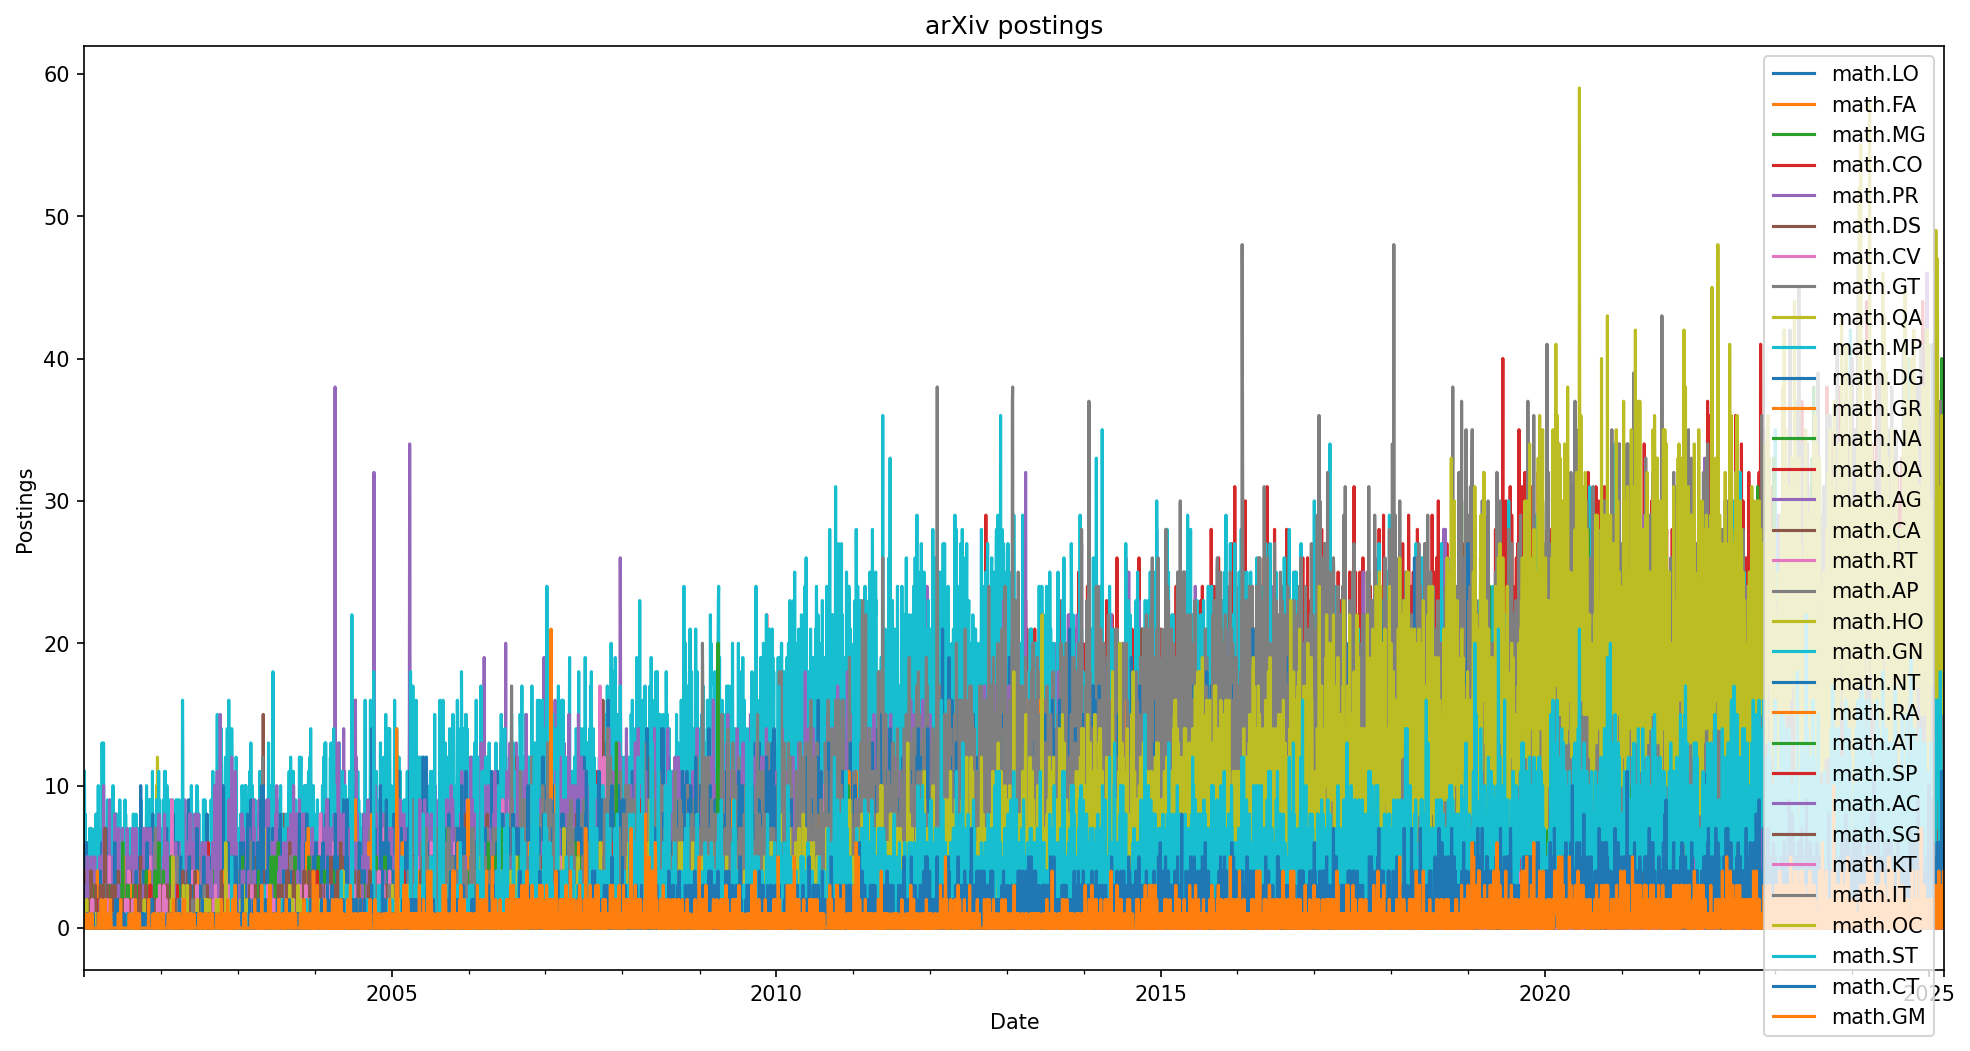

In [4]:
import matplotlib.pyplot as plt

# set plot size
plt.figure(figsize=(16, 8), dpi=150)

# adding the plots
for label, content in df_train.items():
    if label.startswith("math."):  # type: ignore
        content.plot(label=label)

# adding title to the plot
plt.title("arXiv postings")

# adding labels
plt.xlabel("Date")
plt.ylabel("Postings")

# adding legend to the curve
plt.legend()

We also plot `hep-ph` by itself.

Text(0, 0.5, 'Postings')

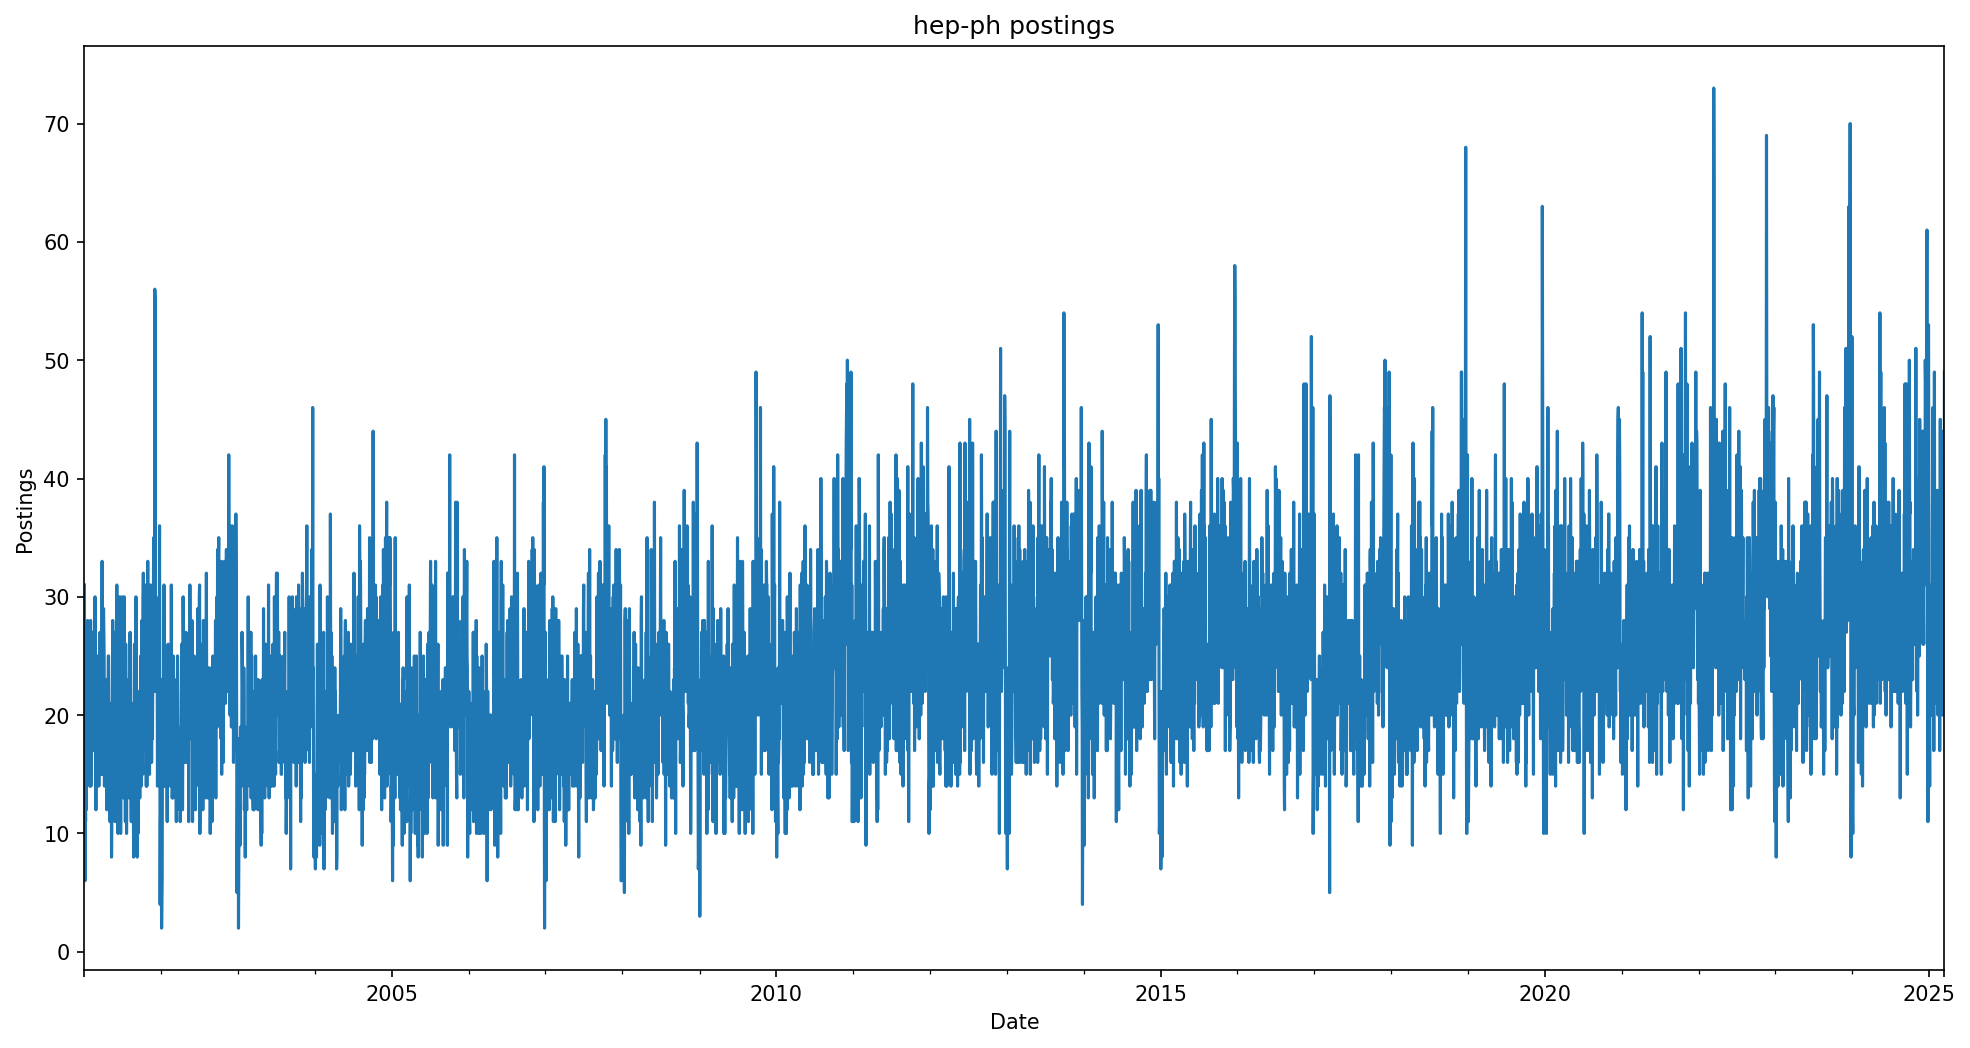

In [5]:
plt.figure(figsize=(16, 8), dpi=150)

df_train["hep-ph"].plot()

plt.title("hep-ph postings")
plt.xlabel("Date")
plt.ylabel("Postings")

We plot autocorrelation and partial autocorrelation for this last time series.

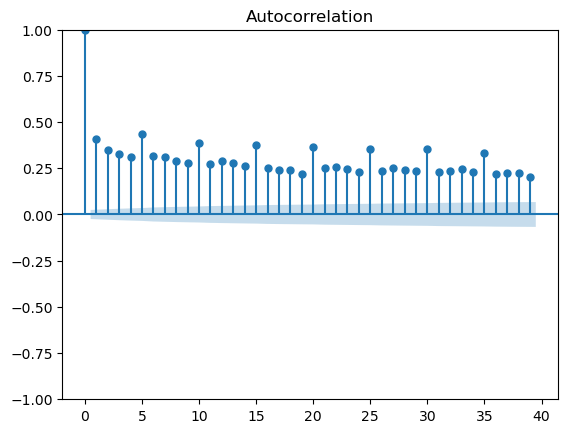

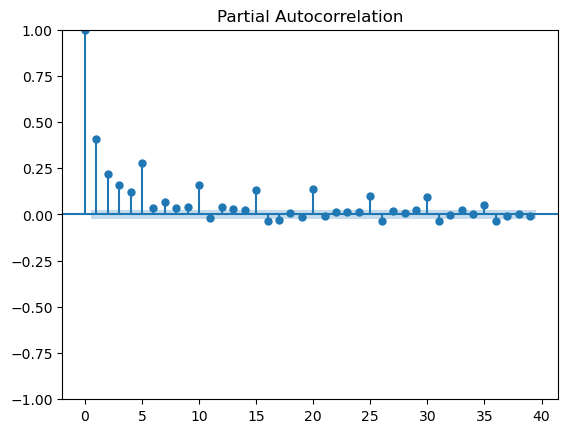

In [6]:
import statsmodels.api as sm

_ = sm.graphics.tsa.plot_acf(df_train["hep-th"])
_ = sm.graphics.tsa.plot_pacf(df_train["hep-th"])

This indicates that the time series has seasonality, with season of a week.  Other categories exhibit similar correlograms, so effective models should likely take weekly seasonality into account.  Looking at the graphs, there is also a global trend to take into account. 

### Baseline models comparison

We prepare a 5-fold validation.  We take a gap of 5 business days between train and validation splits, and we take a test size of 15 business days (our forecasting horizon is 5 business days).

In [7]:
from sklearn.model_selection import TimeSeriesSplit

ts_cv = TimeSeriesSplit(n_splits=5, test_size=15, max_train_size=150)

splits = list(ts_cv.split(df_train))

The models we are going to compare are the following:
- `dummy`: predict the mean of the given window (150 days)
- `t_reg`: linearly regress in time only in the given window
- `day_reg`: linearly regress in the days of the week (as categorical feature)
- `tday_reg`: linearly regress in time and day of the week

All the models above are trained on 150 days windows.

In [8]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

import numpy as np

import json

dummy = DummyRegressor(strategy="mean")
t_reg = LinearRegression()
day_reg = LinearRegression()
tday_reg = LinearRegression()

with open("../data/arxiv-categories.json", "r") as f:
    arxiv_categories_descriptions = json.load(f)

categories = sorted(
    [cat["tag"] for cat in arxiv_categories_descriptions]
    # We exclude ["q-bio", "cond-mat", "astro-ph"] because they disappeared before our sample starting date.
)
results_dict = {}

for category in categories:
    dummy_rmses = np.zeros(5)
    t_rmses = np.zeros(5)
    day_rmses = np.zeros(5)
    tday_rmses = np.zeros(5)
    for i, (train_index, test_index) in enumerate(splits):
        # prepare train data
        df_tt = df_train.iloc[train_index, :]
        df_tt.reset_index(inplace=True)
        df_tt.reset_index(
            inplace=True
        )  # reset index twice to get a column of indexes to use as feature

        # prepare validation data
        df_holdout = df_train.iloc[test_index, :]
        df_holdout.reset_index(inplace=True)
        df_holdout.reset_index(inplace=True)

        # dummy model
        dummy.fit(df_tt[["index"]], df_tt[category])
        dummy_preds = dummy.predict(df_holdout[["index"]])
        dummy_rmses[i] = root_mean_squared_error(df_holdout[category], dummy_preds)

        # t-linear model
        t_reg.fit(df_tt[["index"]], df_tt[category])
        t_preds = t_reg.predict(df_holdout[["index"]])
        t_rmses[i] = root_mean_squared_error(df_holdout[category], t_preds)

        # day-linear model
        day_reg.fit(
            df_tt[["Monday", "Tuesday", "Wednesday", "Thursday"]], df_tt[category]
        )
        day_preds = day_reg.predict(
            df_holdout[["Monday", "Tuesday", "Wednesday", "Thursday"]]
        )
        day_rmses[i] = root_mean_squared_error(df_holdout[category], day_preds)

        # tday-linear model
        tday_reg.fit(
            df_tt[["index", "Monday", "Tuesday", "Wednesday", "Thursday"]],
            df_tt[category],
        )
        tday_preds = tday_reg.predict(
            df_holdout[["index", "Monday", "Tuesday", "Wednesday", "Thursday"]]
        )
        tday_rmses[i] = root_mean_squared_error(df_holdout[category], tday_preds)

    # Different categories have widely different posting rates. To account for
    # that, we rescale the rmses by the max of the category in the training set
    results_dict[category] = (
        np.array(
            [
                dummy_rmses.mean(),
                t_rmses.mean(),
                day_rmses.mean(),
                tday_rmses.mean(),
            ]
        )
        / df_train[category].mean()
    )

We summarize all results in a table.

In [9]:
results = (
    pd.DataFrame(results_dict)
    .join(pd.DataFrame({"model": ["dummy", "t_reg", "day_reg", "tday_reg"]}))
    .set_index("model")
    .transpose()
)

In [10]:
results

model,dummy,t_reg,day_reg,tday_reg
astro-ph.CO,0.511704,0.512749,0.465543,0.467347
astro-ph.EP,0.857071,0.878727,0.837521,0.858652
astro-ph.GA,0.779733,0.763716,0.750331,0.734992
astro-ph.HE,0.730561,0.728496,0.688421,0.686036
astro-ph.IM,0.979021,1.035738,0.929626,0.982687
...,...,...,...,...
stat.CO,1.350181,1.343354,1.318394,1.307019
stat.ME,1.274354,1.284470,0.997009,1.015299
stat.ML,1.040951,1.103664,0.775655,0.859174
stat.OT,3.075093,3.054447,3.084462,3.067074


In [11]:
results.mean()

model
dummy       1.476538
t_reg       1.512796
day_reg     1.379256
tday_reg    1.418297
dtype: float64

Regression on weekdays seems to be the best performing baseline model.

In [12]:
day_is_best = []
margin = []
for index, content in results.iterrows():
    if content.min() == content["day_reg"]:
        day_is_best.append(index)
        margin.append(content["dummy"] - content["day_reg"])

print(
    "Regression on weekdays is the best model for",
    len(day_is_best) / len(categories) * 100,
    "% of the categories.",
)
print()
print("The categories are the following:")
for i in range(len(day_is_best)):
    print("    -", day_is_best[i])
    print("        dummy_rmse - day_rmse =", margin[i])

print()
print("max improvement over dummy =", np.array(margin).max())
print("mean improvement over dummy =", np.array(margin).mean())

Regression on weekdays is the best model for 52.25806451612903 % of the categories.

The categories are the following:
    - astro-ph.CO
        dummy_rmse - day_rmse = 0.04616107035416722
    - astro-ph.EP
        dummy_rmse - day_rmse = 0.019550585046898883
    - astro-ph.IM
        dummy_rmse - day_rmse = 0.04939482854408295
    - cond-mat.dis-nn
        dummy_rmse - day_rmse = 0.03304041983652872
    - cond-mat.mes-hall
        dummy_rmse - day_rmse = 0.09703511450491664
    - cond-mat.mtrl-sci
        dummy_rmse - day_rmse = 0.12870321048627653
    - cond-mat.other
        dummy_rmse - day_rmse = 0.014009790936475697
    - cond-mat.quant-gas
        dummy_rmse - day_rmse = 0.009466090600142252
    - cond-mat.soft
        dummy_rmse - day_rmse = 0.027023032753963394
    - cond-mat.str-el
        dummy_rmse - day_rmse = 0.03411522690263008
    - cs.AI
        dummy_rmse - day_rmse = 0.6539230122590958
    - cs.AR
        dummy_rmse - day_rmse = 0.4835505772050235
    - cs.CE
       

We save the comparisons of the baseline models in `baseline-models-comparison.csv`.

In [13]:
results.to_csv("baseline-models-comparison.csv")